# Grover 算法 

Grover算法是由Lov Grover提出的基于量子Oracle的算法[1]。该问题定义为在给定Oracle访问函数 $f(x)$ 的情况下，在包含 $N$ 个项目的列表中搜索一个项目。该函数具有以下定义属性：如果 $x$ 是我们要查找的项目，则 $f(x)=1$ ；否则，$f(x)=0$ 。针对这个黑盒搜索问题，提出了一种量子算法，它以高概率执行 $O(\sqrt{N})$ 次Oracle查询来找到答案，而任何经典算法都需要 $O(N)$ 次查询。

### 构建Oracle

对于本教程中的示例，我们的"数据库"由量子位所有可能的计算基态组成。例如，如果我们有3个量子位，我们的列表就是态 $|000\rangle,|001\rangle,\dots,|111\rangle$ (即态 $|0\rangle\rightarrow|7\rangle$ )。

Grover算法求解的是给解答态添加负相位的Oracle。即对于计算基中的任意态 $|x\rangle$ ：

$$
U_\omega|x\rangle=\begin{cases} 
\phantom{-}|x\rangle & \text{if }x\neq\omega \\
-|x\rangle & \text{if }x=\omega
\end{cases}
$$

这个Oracle将是一个对角矩阵，其中对应于被标记项目的条目将有一个负相位。例如，如果我们有三个量子位且 $\omega=101$ ，我们的Oracle矩阵为：

$$
U_\omega = 
\begin{bmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\  
0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 &-1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\
\end{bmatrix}
\begin{aligned}
\\
\\
\\
\\  
\\
\leftarrow \omega = 101\\
\\
\\ 
\end{aligned}
$$

Grover算法如此强大，原因在于将问题转化为这种形式的Oracle非常容易。在许多计算问题中，找到解答很困难，但验证解答却相对容易。对于这些问题，我们可以创建一个函数 $f$ ，它接受一个提议的解 $x$ ，如果 $x$ 不是解（ $x\neq\omega$ ）则返回 $f(x)=0$ ，对于有效的解（ $x=\omega$ ）返回 $f(x)=1$ 。然后我们的Oracle可以描述为：

$$
U_\omega|x\rangle=(-1)^{f(x)}|x\rangle  
$$

Oracle的矩阵将是如下形式的对角矩阵：

$$
U_\omega = 
\begin{bmatrix}
(-1)^{f(0)} &   0         & \cdots &   0         \\
0           & (-1)^{f(1)} & \cdots &   0         \\
\vdots      &   0         & \ddots & \vdots      \\
0           &   0         & \cdots & (-1)^{f(2^n-1)} \\  
\end{bmatrix}
$$

### 振幅放大  

那么算法是如何工作的呢？在查看项目列表之前，我们不知道被标记的项目在哪里。因此，任何猜测其位置的尝试都与其他一样有效，这可以用均匀叠加态来表示： $|s\rangle=\frac{1}{\sqrt{N}}\sum_{x=0}^{N-1}|x\rangle$ 。

如果在这一点上，我们按标准基 $\{|x\rangle\}$ 进行测量，这个叠加态会以 $\frac{1}{N}=\frac{1}{2^n}$ 的相同概率坍缩到任何一个基态。因此我们猜对正确值 $w$ 的概率为 $\frac{1}{2^n}$ ，正如预期的那样。因此，平均而言，我们需要尝试大约 $\frac{N}{2}=2^{n-1}$ 次才能猜到正确的项目。

接下来是振幅放大过程，这就是量子计算机显著提高这个概率的方法。该过程拉伸（放大）被标记项目的振幅，同时压缩其他项目的振幅，从而以接近确定性的概率测量到最终态时能返回正确的项目。

该算法在两个反射的几何解释方面有一个很好的几何解释，它们在二维平面内生成旋转。我们需要考虑的唯一两个特殊态是目标态 $|w\rangle$和均匀叠加态 $|s\rangle$ 。这两个向量在向量空间 $\mathbb{C}^N$ 中张成一个二维平面。它们并不完全正交，因为 $|w\rangle$ 也以 $N^{-1/2}$ 的振幅出现在叠加态中。但是，我们可以引入一个额外的态 $|s'\rangle$ ，它位于这两个向量的张成空间中，与 $|w\rangle$ 正交，并通过移除 $|w\rangle$ 并重新归一化从 $|s\rangle$ 获得。

**步骤1**：振幅放大过程从均匀叠加态 $|s\rangle$ 开始，它可以很容易地从 $|s\rangle=H^{\otimes n}|0\rangle^n$ 构造出来。

<div style="margin-right: 15px; border-radius: 10px; background-color: rgb(255， 255， 255); text-align: center;">
    <img src="./images/2_2_0001.png" width="60%"/>
    <p style="padding: 10px; font-size: small; text-align: center; line-height: 0%;">
        <b>
    </p>
</div>

左图对应于由正交向量 $|w\rangle$ 和 $|s'\rangle$ 张成的二维平面，它允许将初始态表示为 $|s\rangle=\sin\theta|w\rangle+\cos\theta|s'\rangle$ ，其中 $\theta=\arcsin\langle s|w\rangle=\arcsin\frac{1}{\sqrt{N}}$ 。右图是态 $|s\rangle$ 的振幅条形图。

**步骤2**：我们将Oracle反射 $U_f$ 应用于态 $|s\rangle$ 。 

<div style="margin-right: 15px; border-radius: 10px; background-color: rgb(255， 255， 255); text-align: center;">
    <img src="./images/2_2_0002.png" width="60%"/>
    <p style="padding: 10px; font-size: small; text-align: center; line-height: 0%;">
        <b>
    </p>
</div>

几何上这对应于态 $|s\rangle$ 关于 $|s'\rangle$ 的反射。这个变换意味着 $|w\rangle$ 态前面的振幅变为负值，这反过来意味着平均振幅（用虚线表示）已经降低。

**步骤3**：现在我们应用关于态 $|s\rangle$ 的额外反射（ $U_s$ ）： $U_s=2|s\rangle\langle s|-I$ 。该变换将态映射到 $U_sU_f|s\rangle$ 并完成变换。

<div style="margin-right: 15px; border-radius: 10px; background-color: rgb(255， 255， 255); text-align: center;">
    <img src="./images/2_2_0003.png" width="60%"/>
    <p style="padding: 10px; font-size: small; text-align: center; line-height: 0%;">
        <b>
    </p>
</div>

两个反射总是对应于一个旋转。变换 $U_sU_f$ 将初始态 $|s\rangle$ 旋转得更接近目标态 $|w\rangle$ 。在振幅条形图中，反射 $U_s$ 的作用可以理解为关于平均振幅的反射。由于第一个反射降低了平均振幅，该变换将 $|w\rangle$ 的负振幅提升到原来的大约三倍，同时降低其他振幅。然后我们回到**步骤2**重复应用。这个过程将重复多次以锁定目标态。

经过 $t$ 步，我们将处于态 $|\psi_t\rangle$ ，其中： $|\psi_t\rangle=(U_sU_f)^t|s\rangle$ 。

我们需要应用旋转多少次？事实证明，大约 $\sqrt{N}$ 次旋转就足够了。当观察态 $|\psi\rangle$ 的振幅时，这一点变得很清楚。我们可以看到 $|w\rangle$ 的振幅随着应用次数线性增长 $\sim tN^{-1/2}$ 。然而，由于我们处理的是振幅而不是概率，向量空间的维度作为平方根出现。因此，在这个过程中被放大的是振幅，而不仅仅是概率。

在有多个解 $M$ 的情况下，可以证明大约需要 $\sqrt{(N/M)}$ 次旋转。

<div style="margin-right: 15px; border-radius: 10px; background-color: rgb(255， 255， 255); text-align: center;">
    <img src="./images/2_2_0004.png" width="60%"/>
    <p style="padding: 10px; font-size: small; text-align: center; line-height: 0%;">
        <b>
    </p>
</div>


## 示例：2个量子比特

让我们首先来看一下使用2个量子比特实现的 Grover 算法在 $N=4$ 的情况[2]。在这种特殊情况下，只需要一次旋转就可以将初始态 $|s\rangle$ 旋转到获胜态 $|w\rangle$：

1. 按照上述介绍，在 $N=4$ 的情况下，我们有：

   $$\theta = \arcsin \frac{1}{2} = \frac{\pi}{6}$$

2. 经过 $t$ 步后，我们得到：
   
   $$(U_s U_\omega)^t  | s \rangle = \sin \theta_t | \omega \rangle + \cos \theta_t | s' \rangle$$
   
   其中：
   
   $$\theta_t = (2t+1)\theta$$

3. 为了获得 $| \omega \rangle$，我们需要 $\theta_t = \frac{\pi}{2}$。将 $\theta=\frac{\pi}{6}$ 代入上式可得 $t=1$。这意味着经过 $t=1$ 次旋转就可以找到目标元素。

下面我们将通过一个使用特定 Oracle 的示例来详细说明。

#### $\lvert \omega \rangle = \lvert 11 \rangle$ 的 Oracle
我们来看 $\lvert w \rangle = \lvert 11 \rangle$ 的情况。此时 Oracle $U_\omega$ 的作用如下：

$$U_\omega | s \rangle = U_\omega \frac{1}{2}\left( |00\rangle + |01\rangle + |10\rangle + |11\rangle \right) = \frac{1}{2}\left( |00\rangle + |01\rangle + |10\rangle - |11\rangle \right)$$

或者用矩阵形式表示为：

$$
U_\omega = 
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\  
0 & 0 & 0 & -1 \\
\end{bmatrix}
$$

你可能会认出这就是受控-Z 门。因此，在这个例子中，我们的 Oracle 就是一个受控-Z 门：

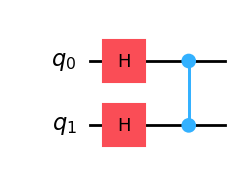

In [3]:
import deepquantum as dq

cir = dq.QubitCircuit(2)
# 制备叠加态
cir.hlayer()
# 加入受控z门做为Oracle
cir.cz(0,1)

cir.draw()

#### 反射 $U_s$
为了完成电路，我们还需要实现额外的反射 $U_s = 2|s\rangle\langle s| - I$。由于这是关于 $|s\rangle$ 的反射，我们希望对每个与 $|s\rangle$ 正交的态都加一个负相位。

实现这一点的一种方法是使用将态 $|s\rangle$ 转换为 $|0\rangle$ 的操作，我们已知对每个量子比特施加 Hadamard 门即可实现：

$$H^{\otimes n}|s\rangle = |0\rangle$$

然后我们再施加一个电路，对所有与 $|0\rangle$ 正交的态都加一个负相位：  

$$U_0 \frac{1}{2}\left( \lvert 00 \rangle + \lvert 01 \rangle + \lvert 10 \rangle + \lvert 11 \rangle \right) = \frac{1}{2}\left( \lvert 00 \rangle - \lvert 01 \rangle - \lvert 10 \rangle - \lvert 11 \rangle \right)$$

即除了 $\lvert 00 \rangle$ 以外，其他每个态的符号都被翻转了。

最后，我们再做一次将态 $|0\rangle$ 转换为态 $|s\rangle$ 的操作(再次使用 H 门)：

$$H^{\otimes n}U_0 H^{\otimes n} = U_s$$

$U_s$ 的完整电路如下所示：

In [4]:
# Us

cir.hlayer()
cir.zlayer()
cir.cz(0,1)
cir.hlayer()

#### $\lvert w \rangle = |11\rangle$ 的完整电路 
由于在 $N=4$ 的特殊情况下只需要一次旋转，因此我们可以将上述组件组合起来，构建 Grover 算法在 $\lvert w \rangle = |11\rangle$ 情况下的完整电路：

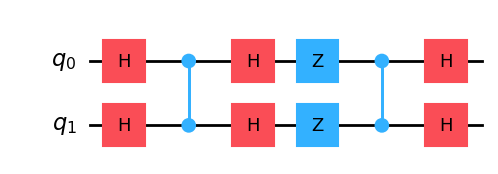

In [5]:
cir.draw()

让我们在模拟中运行这个电路。首先，我们可以验证我们得到了正确的态向量：  

正如预期的那样，除了 $|11\rangle$ 以外所有态的振幅都是 0，这意味着我们有 100% 的概率测量到 $|11\rangle$：

In [6]:
cir()

tensor([[0.0000+0.j],
        [0.0000+0.j],
        [0.0000+0.j],
        [1.0000+0.j]])

# Grover算法总结

1. **初始化状态**：算法起始于全$\vert 0 \rangle$状态。通过对每个量子比特应用Hadamard门操作，我们得到一个均等叠加状态$\vert s \rangle = \frac{\sum_x \vert x \rangle}{\sqrt{N}}$，为接下来的步骤打下基础。

2. **Grover迭代**：算法的核心在于重复执行以下两个步骤，这一过程被称为Grover迭代：
    - 对当前状态相对于状态$\vert w \rangle$进行反射；
    - 接着，对当前状态相对于状态$\vert s \rangle$进行反射。

   这一迭代过程的重复次数为：
   $$
   \text{round}\left(\frac{\pi}{4\arcsin(1/\sqrt{N})} - \frac{1}{2}\right) \approx \frac{\pi\sqrt{N}}{4}
   $$

3. **测量与验证**：经过上述迭代后，进行测量，以不低于$1-\frac{1}{N}$的概率得到搜索问题的解$s$。随后，使用搜索黑盒检验测量结果，以确认其是否为问题的解答。若是，则算法成功完成；若不是，则需要重新运行算法。

通过这一系列步骤，量子搜索算法能以$\sqrt{N}$次操作，在含有$N$个元素的搜索空间中高效地定位被搜索的元素。此算法不仅提高了搜索效率，同时也展示了量子计算在处理复杂问题时的潜力。

# 参考文献

[1] Grover L K. A fast quantum mechanical algorithm for database search[C]//Proceedings of the twenty-eighth annual ACM symposium on Theory of computing. 1996: 212-219.

[2] Nielsen M A, Chuang I L. Quantum computation and quantum information[M]. Cambridge university press, 2010.